## Cuadernillo Práctico - Data Brain
## Análisis de Mejores Rutas con Ciencia de Datos

### Objetivo

Desarrollar un análisis de rutas inteligentes utilizando un dataset simulado de visitantes de un museo para identificar:

- Obras más visitadas
- Tiempo promedio por recorrido
- Rutas más eficientes
- Preferencias de visitantes
- Recomendaciones de recorrido

### Importar librerías

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

import networkx as nx

### Crear Dataset Simulado

In [56]:
np.random.seed(42)

obras = [
    'Pintura Colonial',
    'Escultura Religiosa',
    'Arte Moderno',
    'Fotografía Histórica',
    'Cerámica Indígena',
    'Arquitectura Antigua'
]

visitantes = []

for i in range(20000):
    visitante = {
        'id_visitante': i + 1,
        'obra_visitada': np.random.choice(obras),
        'tiempo_minutos': np.random.randint(2, 20),
        'interes': np.random.choice(['Historia', 'Arte', 'Cultura']),
        'edad': np.random.randint(15, 70),
        'sala': np.random.randint(1, 7)
    }
    visitantes.append(visitante)

museum_df = pd.DataFrame(visitantes)

museum_df.head()

,id_visitante,obra_visitada,tiempo_minutos,interes,edad,sala
0,1,Fotografía Histórica,16,Cultura,22,5
1,2,Cerámica Indígena,8,Arte,33,3
2,3,Arte Moderno,5,Cultura,36,5
3,4,Escultura Religiosa,13,Arte,52,2
4,5,Fotografía Histórica,2,Arte,36,5


### Exploración Inicial del Dataset

In [57]:
museum_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_visitante    20000 non-null  int64 
 1   obra_visitada   20000 non-null  object
 2   tiempo_minutos  20000 non-null  int64 
 3   interes         20000 non-null  object
 4   edad            20000 non-null  int64 
 5   sala            20000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 937.6+ KB


In [58]:
museum_df.describe()

,id_visitante,tiempo_minutos,edad,sala
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,10.502900,42.053300,3.498750
std,5773.647028,5.187932,15.906128,1.704331
min,1.000000,2.000000,15.000000,1.000000
25%,5000.750000,6.000000,28.000000,2.000000
50%,10000.500000,11.000000,42.000000,3.000000
75%,15000.250000,15.000000,56.000000,5.000000
max,20000.000000,19.000000,69.000000,6.000000


In [59]:
museum_df['obra_visitada'].value_counts()

obra_visitada
Arquitectura Antigua    3414
Escultura Religiosa     3364
Pintura Colonial        3364
Fotografía Histórica    3351
Cerámica Indígena       3274
Arte Moderno            3233
Name: count, dtype: int64

### Visualización de Obras Más Visitadas

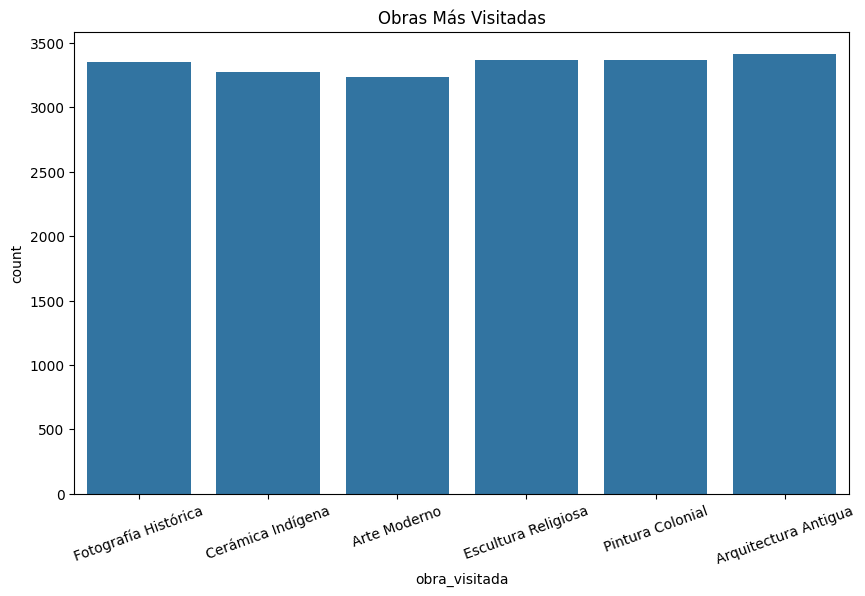

In [60]:
plt.figure(figsize=(10,6))
sns.countplot(data=museum_df, x='obra_visitada')
plt.xticks(rotation=20)
plt.title('Obras Más Visitadas')
plt.show()

### Tiempo Promedio por Obra

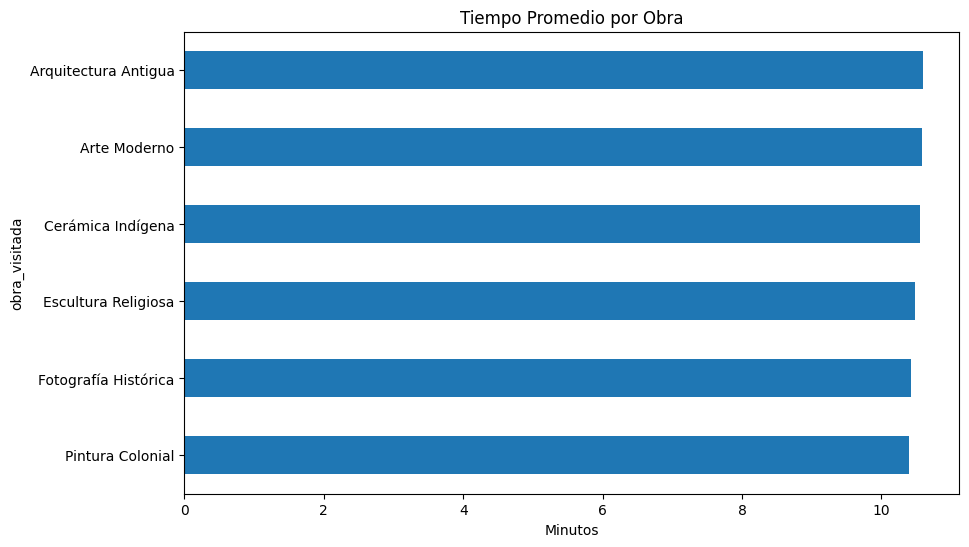

In [61]:
promedio_tiempo = museum_df.groupby('obra_visitada')['tiempo_minutos'].mean()

promedio_tiempo.sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Tiempo Promedio por Obra')
plt.xlabel('Minutos')
plt.show()

### Análisis de Preferencias

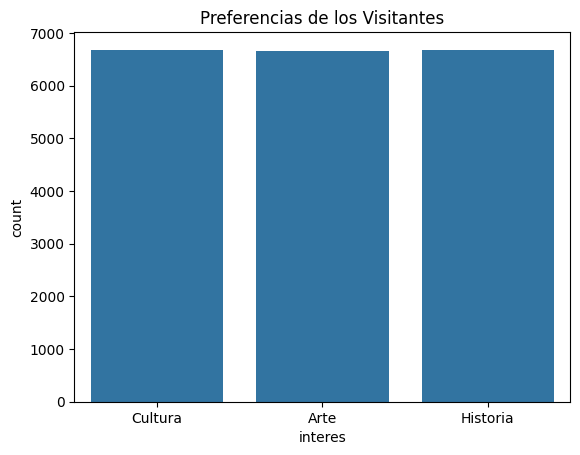

In [62]:
sns.countplot(data=museum_df, x='interes')
plt.title('Preferencias de los Visitantes')
plt.show()

### Preparación de Datos para Machine Learning

In [63]:
encoder = LabelEncoder()

museum_df['obra_encoded'] = encoder.fit_transform(museum_df['obra_visitada'])
museum_df['interes_encoded'] = encoder.fit_transform(museum_df['interes'])

### Clustering de Visitantes

In [64]:
X = museum_df[[
    'tiempo_minutos',
    'edad',
    'obra_encoded',
    'interes_encoded'
]]

kmeans = KMeans(n_clusters=3, random_state=42)

museum_df['cluster'] = kmeans.fit_predict(X)

museum_df.head()

,id_visitante,obra_visitada,tiempo_minutos,interes,edad,sala,obra_encoded,interes_encoded,cluster
0,1,Fotografía Histórica,16,Cultura,22,5,4,1,2
1,2,Cerámica Indígena,8,Arte,33,3,2,0,0
2,3,Arte Moderno,5,Cultura,36,5,1,1,0
3,4,Escultura Religiosa,13,Arte,52,2,3,0,1
4,5,Fotografía Histórica,2,Arte,36,5,4,0,0


### Visualización de Clusters

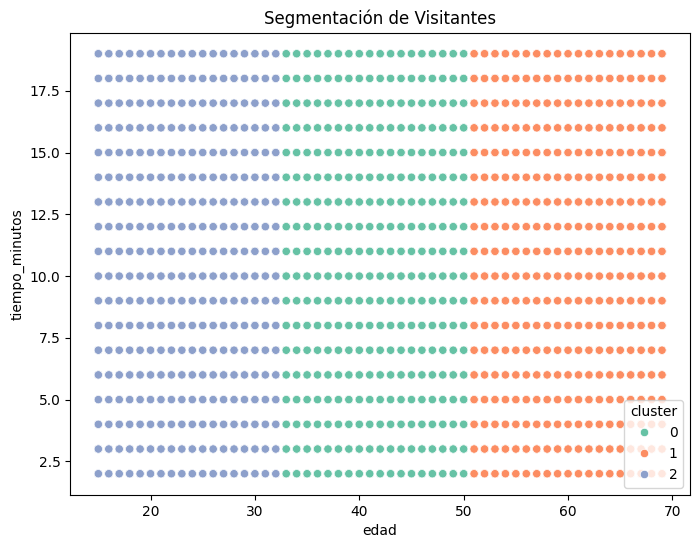

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=museum_df,
    x='edad',
    y='tiempo_minutos',
    hue='cluster',
    palette='Set2'
)

plt.title('Segmentación de Visitantes')
plt.show()

### Construcción de Rutas Inteligentes

In [66]:
G = nx.Graph()

salas = [1,2,3,4,5,6]

for sala in salas:
    G.add_node(sala)

conexiones = [
    (1,2),
    (2,3),
    (3,4),
    (4,5),
    (5,6),
    (1,3),
    (2,5)
]

G.add_edges_from(conexiones)

### Visualización del Mapa de Rutas

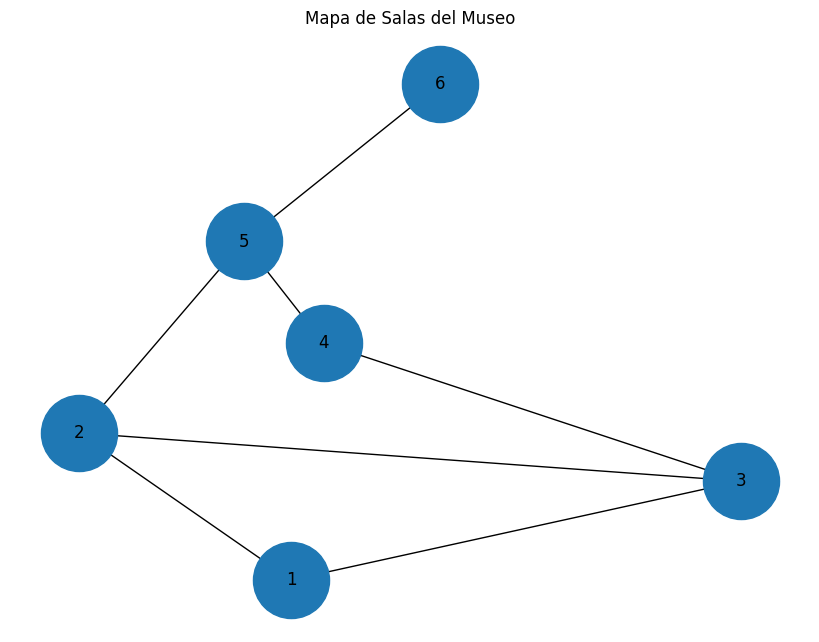

In [67]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=12
)

plt.title('Mapa de Salas del Museo')
plt.show()

### Encontrar la Mejor Ruta

In [68]:
ruta = nx.shortest_path(G, source=1, target=6)

print('Mejor ruta sugerida:')
print(ruta)

Mejor ruta sugerida:
[1, 2, 5, 6]


### Sistema Básico de Recomendación

In [69]:
interes_usuario = 'Historia'

recomendadas = museum_df[
    museum_df['interes'] == interes_usuario
]['obra_visitada'].value_counts()

print(recomendadas)

obra_visitada
Pintura Colonial        1144
Escultura Religiosa     1137
Fotografía Histórica    1133
Cerámica Indígena       1100
Arquitectura Antigua    1091
Arte Moderno            1068
Name: count, dtype: int64


### Dashboard Básico de Resultados

In [70]:
print('Total visitantes:', len(museum_df))
print('Tiempo promedio:', museum_df['tiempo_minutos'].mean())
print('Obra más visitada:', museum_df['obra_visitada'].mode()[0])

Total visitantes: 20000
Tiempo promedio: 10.5029
Obra más visitada: Arquitectura Antigua


### Exportar Dataset

In [71]:
museum_df.to_csv('museum_data.csv', index=False)